# Parte I. KDD, EDA y procesamiento distribuido con Spark

**Integrantes:** Ricardo Amiel Acuña Villogas, Juan Leibniz Aquino Espinoza y Camilo Ernesto Soto Cristóbal.

**Dataset:** Contrataciones Abiertas del Perú, estándar OCDS. Paquetes anuales 2023 a 2025 del Registro de Datos de Open Contracting Partnership, publicación 135 (Perú, OECE).
https://data.open-contracting.org/es/publication/135

**Preguntas de interés.** 
1) Qué tan concentrado está el gasto en pocos proveedores y si eso cambia por territorio. 
2) Qué relación hay entre número de postores y monto. 
3) Si hay apresuramiento del gasto en el cierre del ejercicio.

El porqué de cada decisión de este notebook está en docs/JUSTIFICACION.md. Aquí van solo el resultado y su lectura.

In [ ]:
import sys, time
from pathlib import Path

# Los ayudantes del proyecto viven en notebooks/scripts. Se importan por
# nombre, no con asterisco, para que quede claro de donde sale cada uno.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "notebooks" / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import Window
from pyspark.sql import functions as F

from scripts.helpers import (PARQUET, FIGS, ARTEFACTOS, FIGURAS, PALETA,
                     AZUL, ROJO, VERDE, MORADO, TEAL, TINTA, SUAVE, fmt,
                     abrir_spark, cronometro, medir, figura, exportar,
                     barras_h, lineas, barras_agrupadas, mapa_calor, lorenz, gini)
from scripts.ingesta import asegurar_datos, construir_tabla, limpiar, CRUDO, PERIODOS

pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 64)

spark = abrir_spark("P1-KDD-EDA")
pd.DataFrame([{"spark": spark.version, "nucleos": spark.sparkContext.defaultParallelism,
               "shuffle_partitions": spark.conf.get("spark.sql.shuffle.partitions")}])

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/02 09:57:13 WARN Utils: Your hostname, germain-ThinkPad-E15-Gen-2, resolves to a loopback address: 127.0.1.1; using 192.168.1.27 instead (on interface wlp0s20f3)
26/10/02 09:57:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/02 09:57:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


,spark,nucleos,shuffle_partitions
0,4.2.0,8,16


## 1. Selección

De las 21 tablas del paquete OCDS se usan 5 y se desnormalizan a una fila por proceso. Todo se lee como texto: si Spark infiriera el esquema, el código CUBSO de 16 dígitos pasaría a coma flotante y perdería los dígitos que identifican el ítem.

In [2]:
# Descarga los paquetes anuales si faltan. Esto es lo que permite ejecutar
# el notebook de cero en otra maquina sin pasos manuales previos.
asegurar_datos()

cruda = construir_tabla(spark).cache()
print(f"{cruda.count():,} procesos, {len(cruda.columns)} columnas")
cruda.printSchema()

  2023: ya presente
  2024: ya presente
  2025: ya presente
  CSV disponibles: 2.98 GB


281,462 procesos, 23 columnas
root
 |-- ocid: string (nullable = true)
 |-- comprador_id: string (nullable = true)
 |-- periodo_archivo: string (nullable = false)
 |-- fecha: timestamp (nullable = true)
 |-- fecha_registro: timestamp (nullable = true)
 |-- objeto: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- metodo: string (nullable = true)
 |-- comprador_nombre: string (nullable = true)
 |-- monto_pen: double (nullable = true)
 |-- moneda: string (nullable = true)
 |-- n_postores: double (nullable = true)
 |-- anio: integer (nullable = true)
 |-- mes: integer (nullable = true)
 |-- anio_mes: string (nullable = true)
 |-- nivel_gobierno: string (nullable = false)
 |-- proveedor_id: string (nullable = true)
 |-- proveedor_nombre: string (nullable = true)
 |-- n_proveedores: long (nullable = false)
 |-- items: array (nullable = false)
 |    |-- element: string (containsNull = false)
 |-- n_items: long (nullable = false)
 |-- departamento: string (nullable = true

## 2. Perfilado y calidad

Antes de decidir nada se mide. La cardinalidad va con HyperLogLog y no con un conteo exacto, porque solo hace falta el orden de magnitud para distinguir identificador, categórica y continua.

In [3]:
n = cruda.count()
perfil = cruda.agg(*[x for c, t in cruda.dtypes for x in (
    F.sum(F.col(c).isNull().cast("long")).alias(f"nulos~{c}"),
    (F.lit(None).cast("long") if t.startswith("array")
     else F.approx_count_distinct(c, 0.02)).alias(f"card~{c}"))]).collect()[0].asDict()

perfil = pd.DataFrame([{"columna": c, "tipo": t,
                        "pct_nulos": round(100 * (perfil[f"nulos~{c}"] or 0) / n, 2),
                        "distintos": perfil[f"card~{c}"]}
                       for c, t in cruda.dtypes]).sort_values("pct_nulos", ascending=False)
exportar(perfil, "p1_perfil", "Nulos y cardinalidad de cada columna antes de limpiar")
perfil.head(12)

,columna,tipo,pct_nulos,distintos
17,proveedor_nombre,string,21.96,81955.0
16,proveedor_id,string,21.96,99896.0
11,n_postores,double,8.26,181.0
3,fecha,timestamp,0.00,220289.0
0,ocid,string,0.00,276949.0
1,comprador_id,string,0.00,3076.0
2,periodo_archivo,string,0.00,3.0
6,categoria,string,0.00,3.0
5,objeto,string,0.00,237298.0
4,fecha_registro,timestamp,0.00,277238.0


Tres cosas que el perfil deja ver. El monto no tiene un solo nulo, pero el valor faltante viene codificado como cero. El proveedor falta en uno de cada cinco procesos, que son los desiertos o anulados. Y el año muestra trece valores distintos pese a que se bajaron tres paquetes anuales.

In [4]:
diagnostico = cruda.select(
    F.count("*").alias("filas"),
    F.countDistinct("ocid").alias("ocid_unicos"),
    F.sum((F.col("monto_pen") == 0).cast("int")).alias("monto_cero"),
    F.sum((F.col("anio") < 2023).cast("int")).alias("convocados_antes_2023"),
    F.sum((~F.col("adjudicado")).cast("int")).alias("sin_adjudicacion"),
).toPandas()
exportar(diagnostico, "p1_diagnostico", "Inconsistencias detectadas antes de limpiar")
diagnostico.T.rename(columns={0: "conteo"})

,conteo
filas,281462
ocid_unicos,281462
monto_cero,22830
convocados_antes_2023,82946
sin_adjudicacion,61807



Lectura de f01_paquete_vs_anio
Si cada paquete trajera solo sus propios procesos, toda la masa estaría en la diagonal. No es así: 82,946 filas corresponden a convocatorias anteriores a 2023 que recién entonces se publicaron o corrigieron, y en el paquete 2024 casi la mitad son de 2015 y 2016. Dejarlas haría que la serie temporal muestre actividad de contratación donde en realidad hubo saneamiento de registros nueve años después. Esto justifica recortar la ventana.



,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
periodo_archivo,,,,,,,,,,,,,
2023,0,2,1481,2074,5,8,24,81,270,1952,40392,0,0
2024,0,9,14979,17917,43,48,122,403,1149,14022,13418,47612,0
2025,52,1289,15305,3133,5034,43,84,293,820,2304,18720,18553,59821


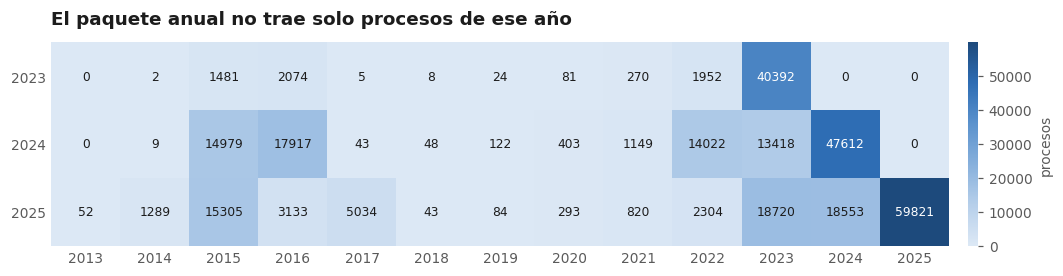

In [5]:
cruce = (cruda.groupBy("periodo_archivo").pivot("anio").count()
         .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo").fillna(0))

fig, _ = mapa_calor(cruce, "El paquete anual no trae solo procesos de ese año", "procesos")
fuera = int(cruce.loc[:, [c for c in cruce.columns if int(c) < 2023]].values.sum())
figura(fig, "f01_paquete_vs_anio", f"""
Si cada paquete trajera solo sus propios procesos, toda la masa estaría en la diagonal.
No es así: {fuera:,} filas corresponden a convocatorias anteriores a 2023 que recién
entonces se publicaron o corrigieron, y en el paquete 2024 casi la mitad son de 2015 y 2016.
Dejarlas haría que la serie temporal muestre actividad de contratación donde en realidad
hubo saneamiento de registros nueve años después. Esto justifica recortar la ventana.""")
exportar(cruce.reset_index(), "p1_paquete_vs_anio", "Año del paquete frente a año de convocatoria")
cruce.astype(int)

## 3. Limpieza

Seis decisiones. Dos descartan filas, una imputa, una marca sin eliminar, una recorta y una normaliza texto. Cada una registra cuántas filas tocó. Las dos que más cuestan son el descarte de montos no positivos y el recorte de la ventana temporal.

In [6]:
limpia, bitacora = limpiar(cruda)
limpia = limpia.cache()
print(f"{cruda.count():,} filas  ->  {limpia.count():,} filas "
      f"({100*limpia.count()/cruda.count():.1f} % conservado)")
exportar(bitacora, "p1_bitacora", "Bitacora de limpieza con filas afectadas por cada decision")
bitacora

281,462 filas  ->  177,398 filas (63.0 % conservado)


,paso,detalle,filas_afectadas,filas_restantes
0,entrada,tabla analitica cruda,0,281462
1,duplicados,"una fila por ocid, la mas reciente",0,281462
2,descarte,monto_pen nulo o no positivo,22830,258632
3,descarte,fecha fuera de 2023 a 2025,81234,177398
4,imputacion,n_postores con la mediana de su metodo,6655,177398
5,marca,"monto fuera de [6.37, 17.99] en escala log, se conserva",565,177398
6,recorte,"n_postores winsorizado al percentil 99,9, tope 107",263,177398



Lectura de f02_embudo
Se pierden 104,064 filas en total, y casi todas en dos pasos: los montos no positivos y la ventana temporal. Los demás pasos imputan, marcan o recortan sin perder ninguna fila, que es lo que se busca: eliminar es la última opción, no la primera.



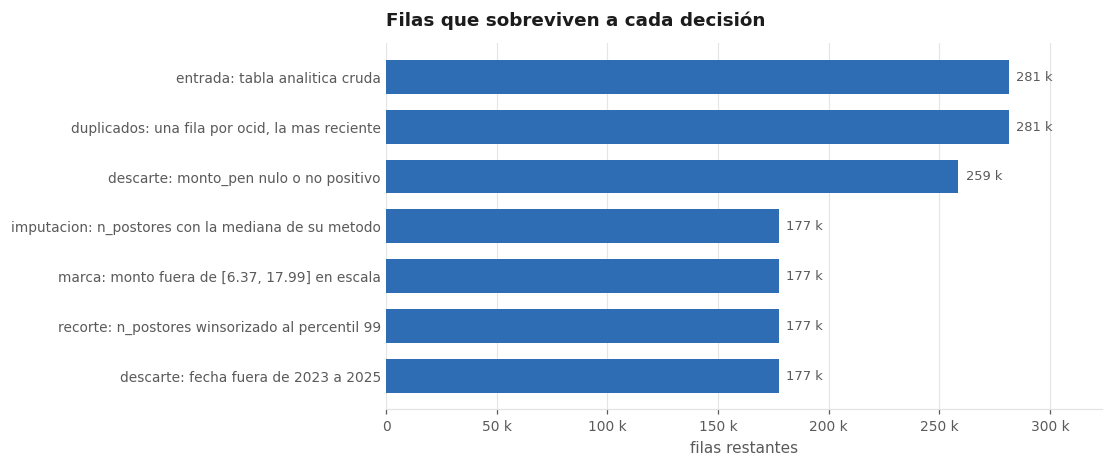

In [7]:
embudo = bitacora[["paso", "detalle", "filas_restantes"]].copy()
embudo["etapa"] = embudo["paso"] + ": " + embudo["detalle"].str.slice(0, 38)
fig, _ = barras_h(embudo, "etapa", "filas_restantes",
                  "Filas que sobreviven a cada decisión", "filas restantes", alto=0.46)
perdidas = int(bitacora.filas_restantes.iloc[0] - bitacora.filas_restantes.iloc[-1])
figura(fig, "f02_embudo", f"""
Se pierden {perdidas:,} filas en total, y casi todas en dos pasos: los montos no positivos
y la ventana temporal. Los demás pasos imputan, marcan o recortan sin perder ninguna fila,
que es lo que se busca: eliminar es la última opción, no la primera.""")

In [8]:
# Verificacion de la reparacion de codificacion. Los reparables deben dar cero.
reparables = {"¥": "Ñ", "¢": "ó", "à": "Ó", "Ö": "Í",
              "µ": "Á", "\u0090": "É", "Ò": "Ó", "Ì": "Í"}
ambiguos = {"¿": "interrogacion invertida", "´": "acento suelto"}
verif = pd.DataFrame([
    {"codigo": f"U+{ord(c):04X}", "trato": f"reparado a {d}" if c in reparables else f"conservado, {d}",
     "filas": limpia.filter(F.col("objeto").contains(c)).count()}
    for c, d in {**reparables, **ambiguos}.items()])
exportar(verif, "p1_codificacion", "Caracteres corrompidos reparados y conservados")
verif

,codigo,trato,filas
0,U+00A5,reparado a Ñ,0
1,U+00A2,reparado a ó,0
2,U+00E0,reparado a Ó,0
3,U+00D6,reparado a Í,0
4,U+00B5,reparado a Á,0
5,U+0090,reparado a É,0
6,U+00D2,reparado a Ó,6
7,U+00CC,reparado a Í,5
8,U+00BF,"conservado, interrogacion invertida",31547
9,U+00B4,"conservado, acento suelto",143


## 4. Transformación y persistencia

La tabla se guarda en Parquet particionado por año. Parquet es columnar, así que el EDA lee dos o tres columnas de veinticinco en vez de la fila entera, y la partición permite descartar directorios sin abrirlos.

In [9]:
limpia.write.mode("overwrite").partitionBy("anio").parquet(str(PARQUET))
datos = spark.read.parquet(str(PARQUET))
datos.createOrReplaceTempView("contrataciones")

crudo_mb = sum(f.stat().st_size for f in (RAIZ / "data/raw").rglob("*.csv")) / 1e6
pq_mb = sum(f.stat().st_size for f in PARQUET.rglob("*.parquet")) / 1e6
print(f"CSV crudo: {crudo_mb/1000:.2f} GB  ->  Parquet: {pq_mb:.1f} MB")
print(f"Filas: {datos.count():,}  Particiones fisicas: "
      f"{sorted(p.name for p in PARQUET.glob('anio=*'))}")

exportar(pd.DataFrame([{"procesos_crudos": int(bitacora.filas_restantes.iloc[0]),
                        "procesos_limpios": datos.count(),
                        "gb_csv": round(crudo_mb / 1000, 3),
                        "mb_parquet": round(pq_mb, 1)}]),
         "p1_portada", "Cifras de portada para el reporte interactivo de la Parte VI")

CSV crudo: 2.98 GB  ->  Parquet: 29.8 MB
Filas: 177,398  Particiones fisicas: ['anio=2023', 'anio=2024', 'anio=2025']


,procesos_crudos,procesos_limpios,gb_csv,mb_parquet
0,281462,177398,2.976,29.8


## 5. Análisis exploratorio

Todo el cálculo ocurre en Spark; a pandas solo llega el agregado ya reducido. Cada figura lleva su lectura debajo.


Lectura de f03_procesos_mes
Diciembre es el máximo de su año en los dos años con cobertura completa: 7,280 procesos en 2023 y 6,498 en 2024. La cola de 2025 cae a 3,380 en noviembre y 942 en diciembre, muy por debajo del nivel habitual: eso no es menos contratación sino subcobertura, porque los procesos tardan en entrar al registro OCDS. La Parte IV debe respetar ese límite.



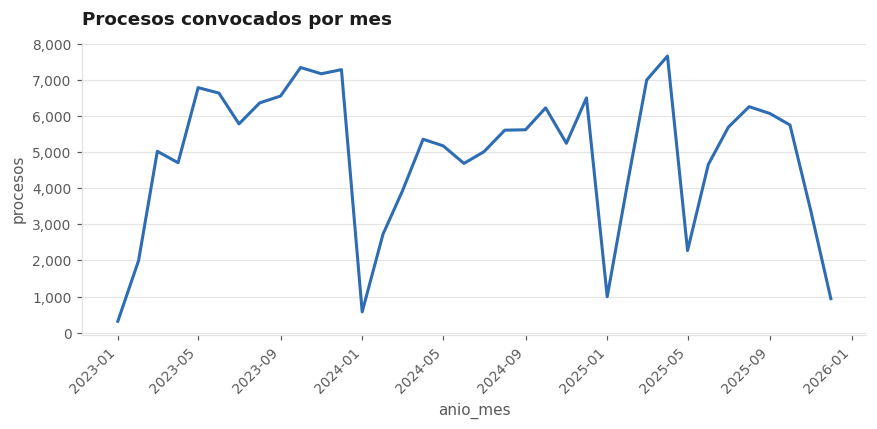

In [10]:
mensual = spark.sql(r"""
    SELECT anio_mes, COUNT(*) AS procesos, SUM(monto_pen)/1e6 AS monto_millones
    FROM contrataciones GROUP BY anio_mes ORDER BY anio_mes""").toPandas()
mensual["anio_mes"] = pd.to_datetime(mensual["anio_mes"])
exportar(mensual, "p1_serie_mensual", "Procesos y monto por mes")

fig, _ = lineas(mensual, "anio_mes", ["procesos"], "Procesos convocados por mes", "procesos")
d23 = mensual[mensual.anio_mes.dt.year == 2023]; d24 = mensual[mensual.anio_mes.dt.year == 2024]
dic23 = int(d23[d23.anio_mes.dt.month == 12].procesos.iloc[0])
dic24 = int(d24[d24.anio_mes.dt.month == 12].procesos.iloc[0])
nov25 = int(mensual[mensual.anio_mes == "2025-11-01"].procesos.iloc[0])
dic25 = int(mensual[mensual.anio_mes == "2025-12-01"].procesos.iloc[0])
figura(fig, "f03_procesos_mes", f"""
Diciembre es el máximo de su año en los dos años con cobertura completa: {dic23:,} procesos
en 2023 y {dic24:,} en 2024. La cola de 2025 cae a {nov25:,} en noviembre y {dic25:,} en
diciembre, muy por debajo del nivel habitual: eso no es menos contratación sino subcobertura,
porque los procesos tardan en entrar al registro OCDS. La Parte IV debe respetar ese límite.""")


Lectura de f04_monto_mes
Se grafica aparte del conteo porque son escalas distintas y un eje doble invitaría a leer una correlación que la figura no sostiene. El máximo de toda la serie es 2024-12 con 14,373 millones de soles, 1.9 veces el mes anterior. El pico de monto es mucho más marcado que el de número de procesos: a fin de año no solo se convoca más, se convoca más caro.



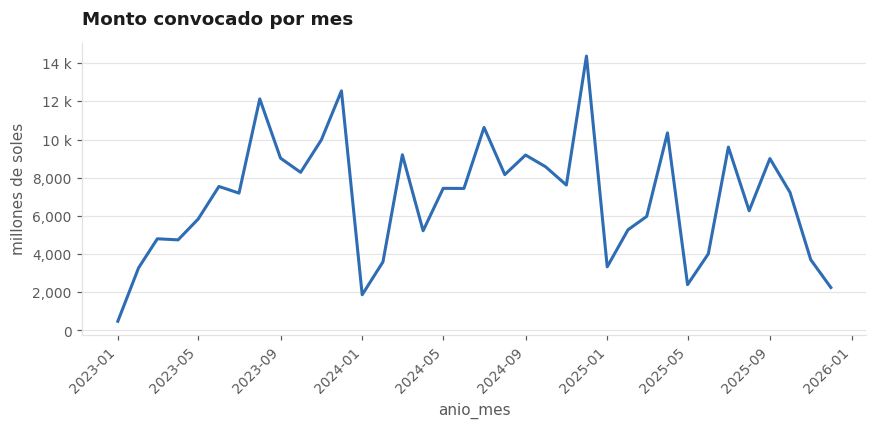

In [11]:
fig, _ = lineas(mensual, "anio_mes", ["monto_millones"],
                "Monto convocado por mes", "millones de soles")
pico = mensual.loc[mensual.monto_millones.idxmax()]
prev = mensual.iloc[mensual.monto_millones.idxmax() - 1]
figura(fig, "f04_monto_mes", f"""
Se grafica aparte del conteo porque son escalas distintas y un eje doble invitaría a leer una
correlación que la figura no sostiene. El máximo de toda la serie es {pico.anio_mes:%Y-%m} con
{pico.monto_millones:,.0f} millones de soles, {pico.monto_millones/prev.monto_millones:.1f} veces
el mes anterior. El pico de monto es mucho más marcado que el de número de procesos: a fin de
año no solo se convoca más, se convoca más caro.""")


Lectura de f05_estacionalidad
Aísla el calendario del ruido de cada año. Las columnas de 2023 y 2024 se oscurecen hacia el último trimestre y alcanzan su máximo en diciembre; la de 2025 se apaga al final por la subcobertura ya señalada. Que el patrón se repita en los dos años completos es lo que permite atribuirlo al cierre del ejercicio presupuestal y no a un año particular.



anio,2023,2024,2025
ene,316,576,995
feb,1995,2722,4202
mar,5020,3918,6995
abr,4704,5354,7656
may,6782,5171,2273
jun,6631,4685,4655
jul,5779,5010,5689
ago,6361,5605,6255
sep,6549,5616,6066
oct,7339,6223,5748


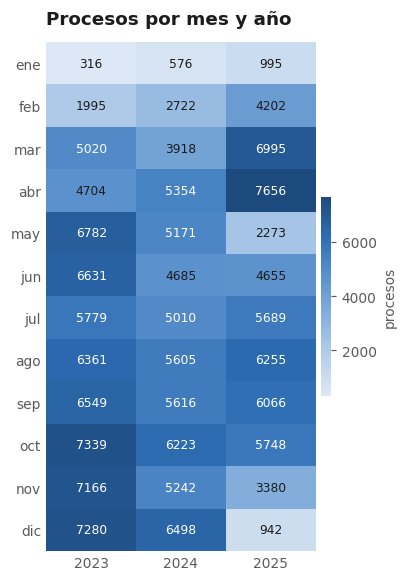

In [12]:
estacional = (spark.sql("SELECT mes, anio, COUNT(*) AS n FROM contrataciones GROUP BY mes, anio")
              .toPandas().pivot(index="mes", columns="anio", values="n").fillna(0))
estacional.index = ["ene","feb","mar","abr","may","jun","jul","ago","sep","oct","nov","dic"]
fig, _ = mapa_calor(estacional, "Procesos por mes y año", "procesos")
figura(fig, "f05_estacionalidad", f"""
Aísla el calendario del ruido de cada año. Las columnas de 2023 y 2024 se oscurecen hacia el
último trimestre y alcanzan su máximo en diciembre; la de 2025 se apaga al final por la
subcobertura ya señalada. Que el patrón se repita en los dos años completos es lo que permite
atribuirlo al cierre del ejercicio presupuestal y no a un año particular.""")
exportar(estacional.reset_index(names="mes"), "p1_estacionalidad", "Procesos por mes y anio")
estacional.astype(int)


Lectura de f06_distribucion_monto
La media es 7.9 veces la mediana, así que la media no describe a ningún proceso representativo. En escala lineal esta figura sería una sola barra pegada al eje; el logaritmo es lo que la hace legible y lo que justifica haber aplicado el criterio de extremos sobre esa misma escala. Y el dato que decide: los 565 procesos marcados como extremos son el 0.3 % de las filas y concentran el 38 % del gasto. Eliminarlos habría dejado una tabla más ordenada y habría borrado un tercio del dinero público.



,monto_outlier,n,mm
0,True,565,93648.597951
1,False,176833,154957.521546


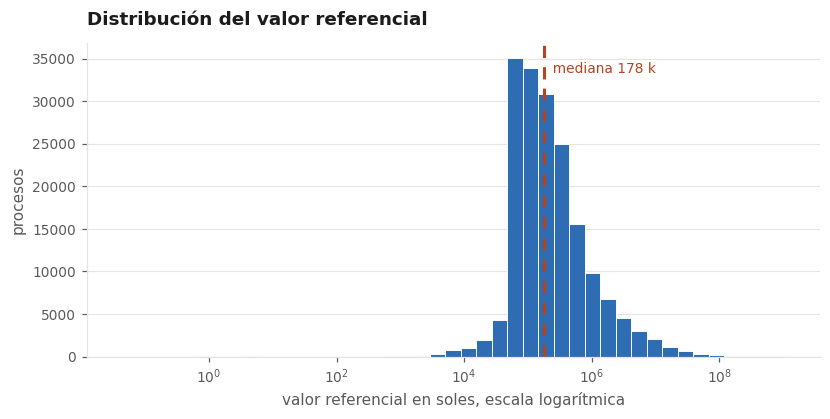

In [13]:
montos = datos.select("monto_pen").toPandas()["monto_pen"].values
fig, ax = plt.subplots(figsize=(8.6, 3.7))
bordes = np.logspace(np.log10(montos.min()), np.log10(montos.max()), 44)
conteo, _ = np.histogram(montos, bins=bordes)
exportar(pd.DataFrame({"desde": np.round(bordes[:-1], 2), "hasta": np.round(bordes[1:], 2),
                       "procesos": conteo}),
         "p1_histograma_monto", "Histograma del valor referencial en escala logaritmica")
ax.hist(montos, bins=bordes, color=AZUL, edgecolor="white", linewidth=.6)
ax.set_xscale("log"); ax.grid(axis="y", alpha=.9); ax.set_axisbelow(True)
ax.set_xlabel("valor referencial en soles, escala logarítmica"); ax.set_ylabel("procesos")
ax.set_title("Distribución del valor referencial", loc="left", pad=12)
ax.axvline(np.median(montos), color=ROJO, lw=2, ls=(0, (4, 3)))
ax.text(np.median(montos), ax.get_ylim()[1]*.94, f"  mediana {fmt(np.median(montos))}",
        color=ROJO, fontsize=9, va="top")

ext = datos.groupBy("monto_outlier").agg(F.count("*").alias("n"),
                                         (F.sum("monto_pen")/1e6).alias("mm")).toPandas()
e = ext[ext.monto_outlier]; r = ext[~ext.monto_outlier]
pct_filas = 100*e.n.iloc[0]/(e.n.iloc[0]+r.n.iloc[0]); pct_monto = 100*e.mm.iloc[0]/(e.mm.iloc[0]+r.mm.iloc[0])
figura(fig, "f06_distribucion_monto", f"""
La media es {montos.mean()/np.median(montos):.1f} veces la mediana, así que la media no describe
a ningún proceso representativo. En escala lineal esta figura sería una sola barra pegada al eje;
el logaritmo es lo que la hace legible y lo que justifica haber aplicado el criterio de extremos
sobre esa misma escala. Y el dato que decide: los {int(e.n.iloc[0]):,} procesos marcados como
extremos son el {pct_filas:.1f} % de las filas y concentran el {pct_monto:.0f} % del gasto.
Eliminarlos habría dejado una tabla más ordenada y habría borrado un tercio del dinero público.""")
exportar(ext, "p1_outliers", "Procesos marcados como extremos frente al resto")


Lectura de f07_metodo
Contar procesos y contar soles dan rankings casi inversos, y ese desacople es el primer hallazgo no obvio. Adjudicación Simplificada encabeza por volumen con 82,503 procesos pero mueve 47.1 mil millones. Licitación Pública, con 9,242 procesos, mueve 106.6 mil millones, el 46 % del total. Cualquier conclusión que mezcle ambas lecturas será falsa.



,metodo,procesos,monto_mmm,postores_medio
0,Adjudicación Simplificada,82503,47.14,16.14
1,Subasta Inversa Electrónica,21150,10.00,8.23
2,Comparación de Precios,12555,0.85,3.14
3,Contratación Directa,11049,14.53,1.23
4,Licitación Pública Abreviada,9601,6.32,13.61
5,Licitación Pública,9242,106.64,21.02
6,Concurso Público Abreviado,8926,1.92,14.55
7,Concurso Público,6627,27.14,26.07
8,Regímen Especial,4367,4.81,1.64
9,Convenio,4009,10.29,1.98


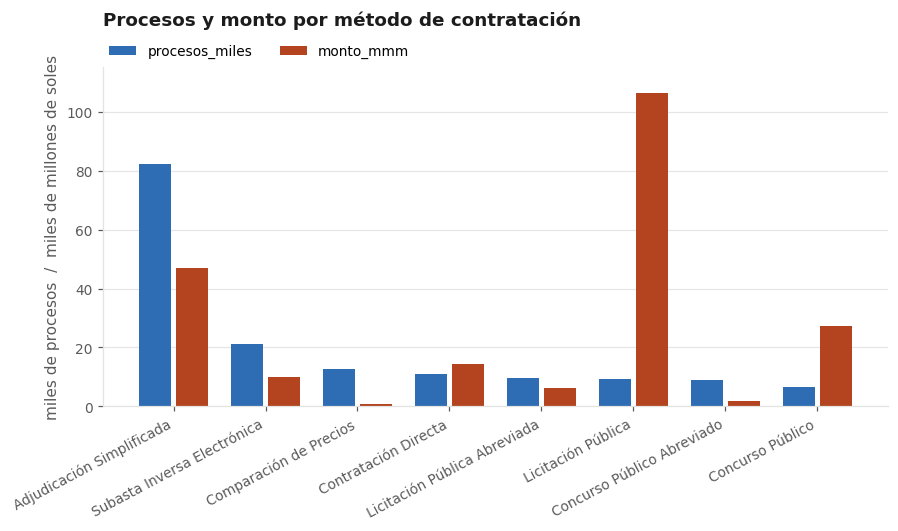

In [14]:
metodo = spark.sql(r"""
    SELECT metodo, COUNT(*) AS procesos, SUM(monto_pen)/1e9 AS monto_mmm,
           AVG(n_postores) AS postores_medio
    FROM contrataciones GROUP BY metodo ORDER BY procesos DESC LIMIT 12""").toPandas()
exportar(metodo, "p1_por_metodo", "Procesos, monto y postores por metodo de contratacion")

fig, _ = barras_agrupadas(metodo.head(8).assign(procesos_miles=lambda d: d.procesos/1000),
                          "metodo", ["procesos_miles", "monto_mmm"],
                          "Procesos y monto por método de contratación",
                          "miles de procesos  /  miles de millones de soles")
top_n = metodo.iloc[0]; top_m = metodo.sort_values("monto_mmm", ascending=False).iloc[0]
tot = metodo.monto_mmm.sum()
figura(fig, "f07_metodo", f"""
Contar procesos y contar soles dan rankings casi inversos, y ese desacople es el primer hallazgo
no obvio. {top_n.metodo} encabeza por volumen con {top_n.procesos:,} procesos pero mueve
{top_n.monto_mmm:,.1f} mil millones. {top_m.metodo}, con {top_m.procesos:,} procesos, mueve
{top_m.monto_mmm:,.1f} mil millones, el {100*top_m.monto_mmm/tot:.0f} % del total. Cualquier
conclusión que mezcle ambas lecturas será falsa.""")
metodo.round(2)


Lectura de f08_nivel_gobierno
Los gobiernos locales convocan 73,456 procesos repartidos en 1,855 entidades, muchos más que cualquier otro grupo, y aun así el gobierno nacional los supera en monto con 29,984 procesos y solo 277 entidades. El nivel de gobierno es una variable derivada por expresión regular sobre el nombre de la entidad, no viene en el dato crudo; la categoría Otro recoge lo que ninguna regla reconoce y es el 6.1 % de los procesos, que es la medida honesta de cuánto falla la derivación.



,nivel_gobierno,procesos,monto_mmm,entidades
0,Gobierno nacional,29984,81.56,277
1,Gobierno regional,39776,63.73,529
2,Gobierno local,73456,62.02,1855
3,Empresa del Estado,8048,15.45,75
4,Otro,10742,13.72,126
5,Universidad publica,7094,5.82,53
6,Fuerzas armadas y policiales,5812,4.66,20
7,Establecimiento de salud,2278,1.56,24
8,Unidad educativa,208,0.10,9


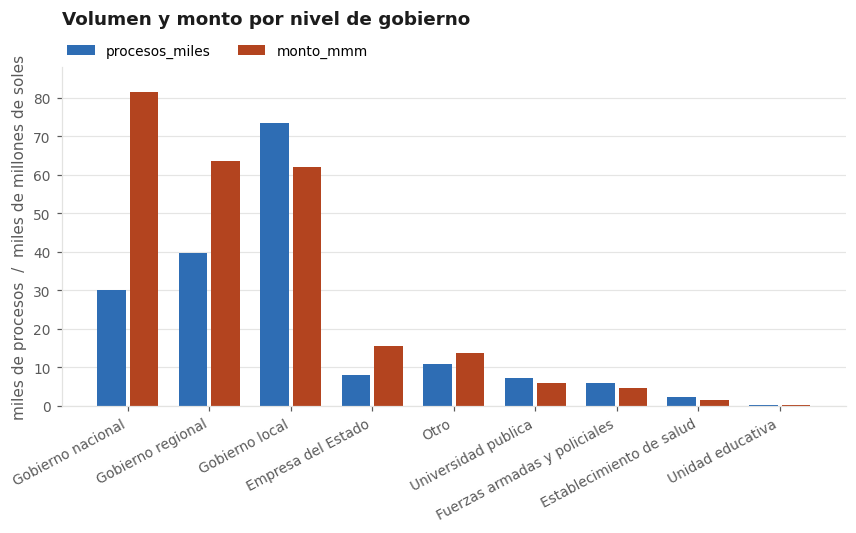

In [15]:
nivel = spark.sql(r"""
    SELECT nivel_gobierno, COUNT(*) AS procesos, SUM(monto_pen)/1e9 AS monto_mmm,
           COUNT(DISTINCT comprador_id) AS entidades
    FROM contrataciones GROUP BY nivel_gobierno ORDER BY monto_mmm DESC""").toPandas()
exportar(nivel, "p1_por_nivel", "Procesos, monto y entidades por nivel de gobierno")

fig, _ = barras_agrupadas(nivel.assign(procesos_miles=lambda d: d.procesos/1000),
                          "nivel_gobierno", ["procesos_miles", "monto_mmm"],
                          "Volumen y monto por nivel de gobierno",
                          "miles de procesos  /  miles de millones de soles")
loc = nivel[nivel.nivel_gobierno == "Gobierno local"].iloc[0]
nac = nivel[nivel.nivel_gobierno == "Gobierno nacional"].iloc[0]
otro = nivel[nivel.nivel_gobierno == "Otro"]
pct_otro = 100*otro.procesos.iloc[0]/nivel.procesos.sum() if len(otro) else 0
figura(fig, "f08_nivel_gobierno", f"""
Los gobiernos locales convocan {loc.procesos:,} procesos repartidos en {loc.entidades:,}
entidades, muchos más que cualquier otro grupo, y aun así el gobierno nacional los supera en
monto con {nac.procesos:,} procesos y solo {nac.entidades} entidades. El nivel de gobierno es
una variable derivada por expresión regular sobre el nombre de la entidad, no viene en el dato
crudo; la categoría Otro recoge lo que ninguna regla reconoce y es el {pct_otro:.1f} % de los
procesos, que es la medida honesta de cuánto falla la derivación.""")
nivel.round(2)


Lectura de f09_top_compradores
Se ordena por monto y no por número de procesos porque la pregunta es a dónde va el dinero, no quién hace más trámites. La entidad que encabeza concentra 18,742 millones en 828 procesos. Estas quince entidades suman 89.9 mil millones de soles.



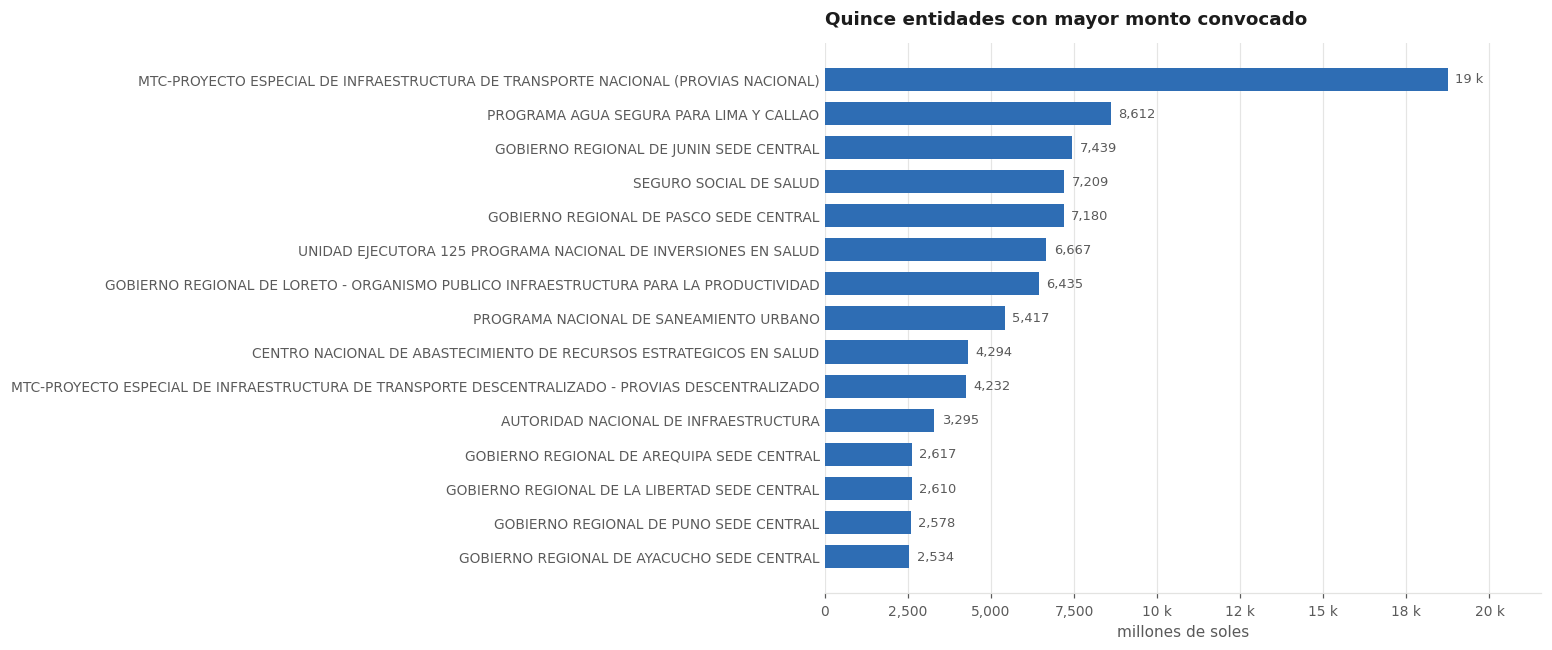

In [16]:
top_c = spark.sql(r"""
    SELECT comprador_nombre, COUNT(*) AS procesos, SUM(monto_pen)/1e6 AS monto_mm
    FROM contrataciones GROUP BY comprador_nombre ORDER BY monto_mm DESC LIMIT 15""").toPandas()
exportar(top_c, "p1_top_compradores", "Quince entidades con mayor monto convocado")
fig, _ = barras_h(top_c, "comprador_nombre", "monto_mm",
                  "Quince entidades con mayor monto convocado", "millones de soles")
figura(fig, "f09_top_compradores", f"""
Se ordena por monto y no por número de procesos porque la pregunta es a dónde va el dinero, no
quién hace más trámites. La entidad que encabeza concentra {top_c.monto_mm.iloc[0]:,.0f} millones
en {top_c.procesos.iloc[0]:,} procesos. Estas quince entidades suman
{top_c.monto_mm.sum()/1000:,.1f} mil millones de soles.""")


Lectura de f10_top_proveedores
Hay dos formas distintas de llegar arriba y el ranking las pone una al lado de la otra sin distinguirlas. Un proveedor acumula 581 millones repartidos en 188 adjudicaciones; otro alcanza 1,135 millones en apenas 1. Recurrencia y magnitud puntual son fenómenos que no se parecen, y separarlos es tarea de la Parte II.



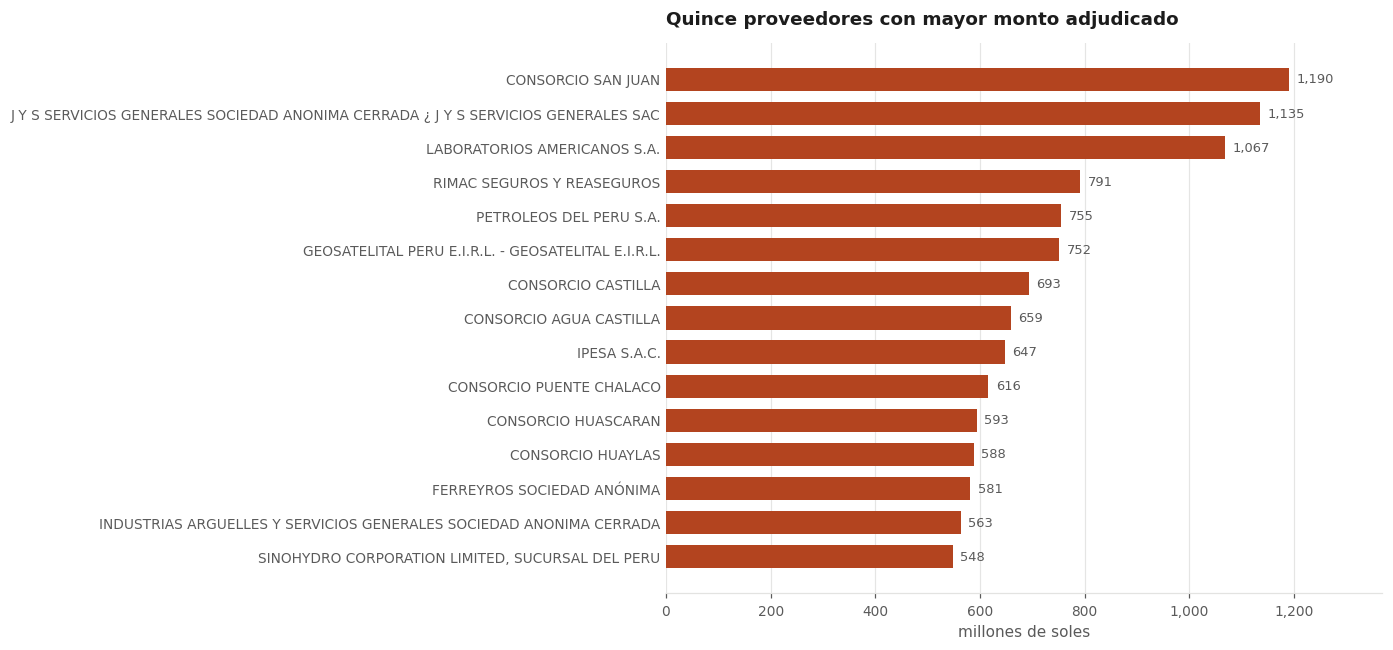

In [17]:
top_p = spark.sql(r"""
    SELECT proveedor_nombre, COUNT(*) AS adjudicaciones, SUM(monto_pen)/1e6 AS monto_mm
    FROM contrataciones WHERE adjudicado
    GROUP BY proveedor_nombre ORDER BY monto_mm DESC LIMIT 15""").toPandas()
exportar(top_p, "p1_top_proveedores", "Quince proveedores con mayor monto adjudicado")
fig, _ = barras_h(top_p, "proveedor_nombre", "monto_mm",
                  "Quince proveedores con mayor monto adjudicado", "millones de soles",
                  color=ROJO)
muchas = top_p.sort_values("adjudicaciones", ascending=False).iloc[0]
pocas = top_p.sort_values("adjudicaciones").iloc[0]
figura(fig, "f10_top_proveedores", f"""
Hay dos formas distintas de llegar arriba y el ranking las pone una al lado de la otra sin
distinguirlas. Un proveedor acumula {muchas.monto_mm:,.0f} millones repartidos en
{muchas.adjudicaciones:,} adjudicaciones; otro alcanza {pocas.monto_mm:,.0f} millones en apenas
{pocas.adjudicaciones}. Recurrencia y magnitud puntual son fenómenos que no se parecen, y
separarlos es tarea de la Parte II.""")


Lectura de f11_lorenz
Un ranking de quince nombres dice quiénes están arriba pero no cuánto pesan. La curva sí, y lo resume en un número comparable: el Gini es 0.857 sobre 67,510 proveedores. El uno por ciento superior se lleva el 47.1 % del monto y el diez por ciento se lleva el 80.2 %. Esta es la respuesta cuantitativa a la pregunta 1.



,tramo,pct_del_monto
0,top 1 %,47.1
1,top 5 %,70.1
2,top 10 %,80.2
3,top 25 %,91.3


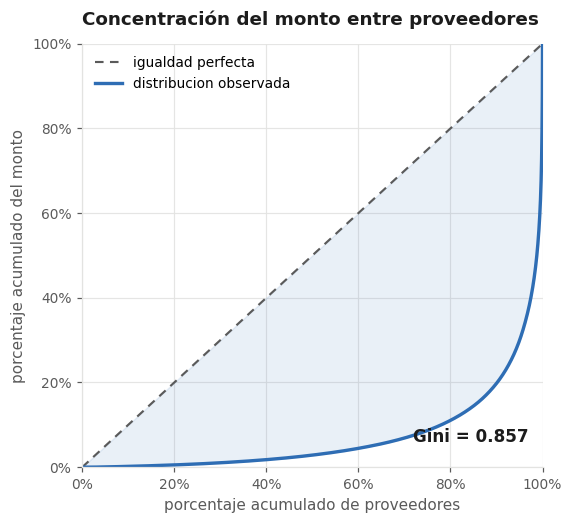

In [18]:
por_prov = (datos.filter("adjudicado").groupBy("proveedor_id")
            .agg(F.sum("monto_pen").alias("monto")).toPandas()["monto"].values)
# La curva completa se exporta remuestreada a 200 puntos para que el reporte de
# la Parte VI pueda dibujarla de verdad, en lugar de interpolar entre tramos.
orden = np.sort(por_prov)
acum = np.cumsum(orden) / orden.sum()
idx = np.unique(np.linspace(0, len(orden) - 1, 200).astype(int))
exportar(pd.DataFrame({"pct_proveedores": np.round((idx + 1) / len(orden), 5),
                       "pct_monto": np.round(acum[idx], 5)}),
         "p1_lorenz", "Curva de Lorenz del monto adjudicado, remuestreada a 200 puntos")

fig, g = lorenz(por_prov, "Concentración del monto entre proveedores", "proveedores")
serie = np.sort(por_prov)[::-1]; total = serie.sum()
hitos = pd.DataFrame([{"tramo": f"top {p} %", "pct_del_monto":
                       round(100*serie[:max(1,int(len(serie)*p/100))].sum()/total, 1)}
                      for p in (1, 5, 10, 25)])
figura(fig, "f11_lorenz", f"""
Un ranking de quince nombres dice quiénes están arriba pero no cuánto pesan. La curva sí, y lo
resume en un número comparable: el Gini es {g:.3f} sobre {len(serie):,} proveedores. El uno por
ciento superior se lleva el {hitos.pct_del_monto.iloc[0]} % del monto y el diez por ciento se
lleva el {hitos.pct_del_monto.iloc[2]} %. Esta es la respuesta cuantitativa a la pregunta 1.""")
exportar(hitos.assign(gini=round(g, 4)), "p1_concentracion", "Concentracion del monto por tramos de proveedores")
hitos


Lectura de f12_gini_departamento
El monto absoluto solo diría que Lima gasta más; el Gini hace comparables mercados de tamaños muy distintos. El resultado va en contra de lo esperado: solo 2 de 25 departamentos superan el Gini nacional de 0.857, y son PASCO, LIMA. El resto queda por debajo. El Gini del país no describe a un mercado regional típico, está empujado hacia arriba por Lima.



,departamento,proveedores,monto_mm,gini
18,PASCO,1282,3545.604,0.909
14,LIMA,20504,72147.903,0.899
8,HUANCAVELICA,1958,2469.456,0.833
15,LORETO,2011,4536.326,0.825
11,JUNIN,3428,5038.684,0.820
21,SAN MARTIN,1810,2946.551,0.806
12,LA LIBERTAD,3295,5268.108,0.797
3,AREQUIPA,3153,4536.433,0.792
13,LAMBAYEQUE,1739,2937.565,0.791
19,PIURA,3282,5449.311,0.789


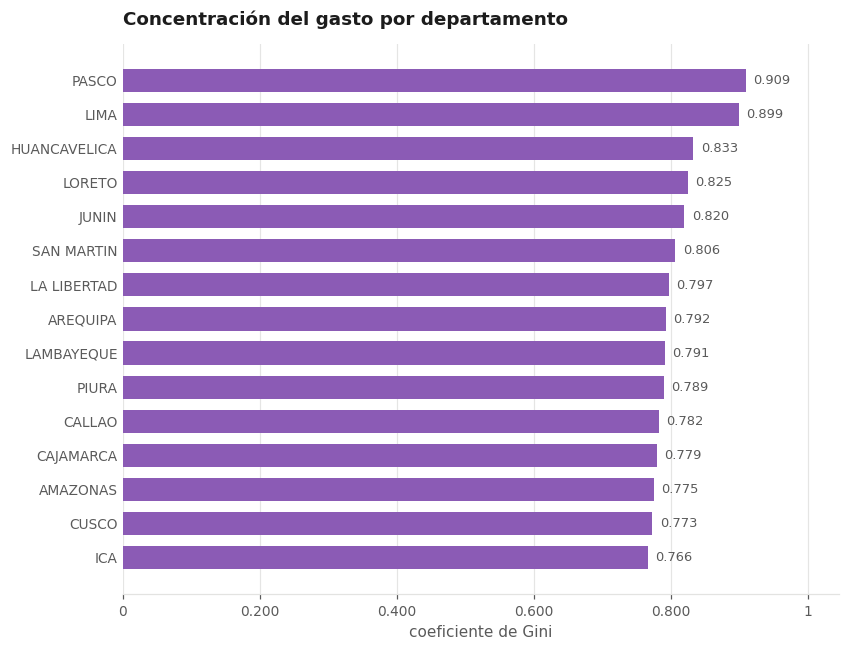

In [19]:
pdp = (datos.filter("adjudicado").groupBy("departamento", "proveedor_id")
       .agg(F.sum("monto_pen").alias("monto")).toPandas())
terr = (pdp.groupby("departamento")
        .agg(proveedores=("proveedor_id", "nunique"),
             monto_mm=("monto", lambda s: s.sum()/1e6),
             gini=("monto", lambda s: gini(s) if len(s) >= 50 else np.nan))
        .dropna().reset_index().sort_values("gini", ascending=False))
exportar(terr, "p1_concentracion_departamento", "Proveedores, monto y Gini por departamento")

fig, _ = barras_h(terr.head(15), "departamento", "gini",
                  "Concentración del gasto por departamento", "coeficiente de Gini",
                  color=MORADO)
encima = terr[terr.gini > g]
figura(fig, "f12_gini_departamento", f"""
El monto absoluto solo diría que Lima gasta más; el Gini hace comparables mercados de tamaños
muy distintos. El resultado va en contra de lo esperado: solo {len(encima)} de
{len(terr)} departamentos superan el Gini nacional de {g:.3f}, y son
{", ".join(encima.departamento.tolist())}. El resto queda por debajo. El Gini del país no
describe a un mercado regional típico, está empujado hacia arriba por Lima.""")
terr.round(3).head(10)


Lectura de f13_competencia
Un diagrama de dispersión con 170,743 puntos sería una mancha; agrupar por tramo muestra la tendencia. El número mediano de postores sí crece con el monto, de 1 a 19. Lo que importa es dónde se rompe: en el tramo más bajo el 57 % de los procesos tuvo un único postor, mientras que en los demás tramos esa proporción se estabiliza cerca del 10 % y ya no baja ni por encima de veinte millones. Son dos fenómenos distintos: una franja pequeña competitiva solo en el papel, y un suelo persistente de uno de cada diez procesos sin competencia. Se excluyen los postores imputados para que la relación no la produzca la propia imputación.



,tramo,procesos,postores_mediano,pct_postor_unico
0,1. menos de 50 mil,10156,1.0,57.01063
1,2. 50 a 200 mil,83628,7.0,10.05883
2,3. 200 mil a 1 M,55872,11.0,8.70740
3,4. 1 a 5 M,15931,15.0,10.01820
4,5. 5 a 20 M,3998,18.0,9.65483
5,6. mas de 20 M,1158,19.0,11.39896


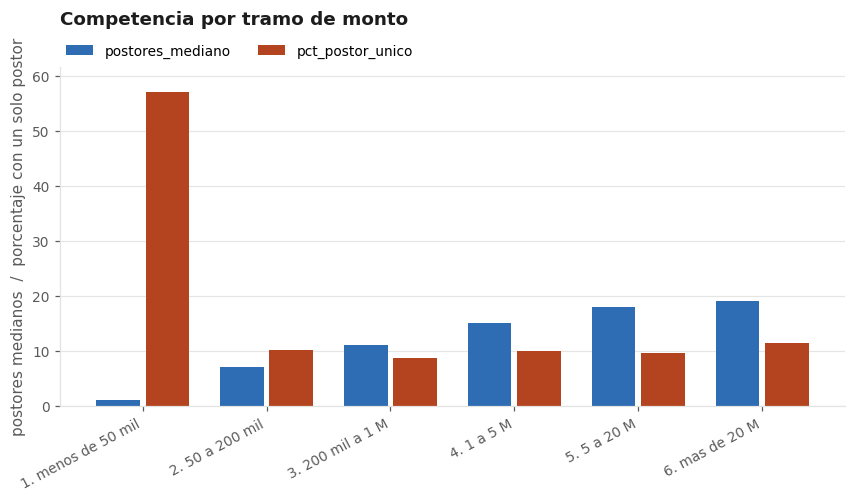

In [20]:
comp = spark.sql(r"""
    SELECT CASE WHEN monto_pen <    50000 THEN '1. menos de 50 mil'
                WHEN monto_pen <   200000 THEN '2. 50 a 200 mil'
                WHEN monto_pen <  1000000 THEN '3. 200 mil a 1 M'
                WHEN monto_pen <  5000000 THEN '4. 1 a 5 M'
                WHEN monto_pen < 20000000 THEN '5. 5 a 20 M'
                ELSE                           '6. mas de 20 M' END AS tramo,
           COUNT(*) AS procesos,
           PERCENTILE_APPROX(n_postores, 0.5) AS postores_mediano,
           AVG(CASE WHEN n_postores <= 1 THEN 100.0 ELSE 0.0 END) AS pct_postor_unico
    FROM contrataciones WHERE NOT n_postores_imputado
    GROUP BY 1 ORDER BY 1""").toPandas()
exportar(comp, "p1_competencia", "Postores medianos y porcentaje de postor unico por tramo de monto")

fig, _ = barras_agrupadas(comp, "tramo", ["postores_mediano", "pct_postor_unico"],
                          "Competencia por tramo de monto",
                          "postores medianos  /  porcentaje con un solo postor")
bajo = comp.iloc[0]; resto = comp.iloc[1:]
figura(fig, "f13_competencia", f"""
Un diagrama de dispersión con {int(comp.procesos.sum()):,} puntos sería una mancha; agrupar por
tramo muestra la tendencia. El número mediano de postores sí crece con el monto, de
{bajo.postores_mediano:.0f} a {comp.postores_mediano.iloc[-1]:.0f}. Lo que importa es dónde se
rompe: en el tramo más bajo el {bajo.pct_postor_unico:.0f} % de los procesos tuvo un único
postor, mientras que en los demás tramos esa proporción se estabiliza cerca del
{resto.pct_postor_unico.mean():.0f} % y ya no baja ni por encima de veinte millones. Son dos
fenómenos distintos: una franja pequeña competitiva solo en el papel, y un suelo persistente de
uno de cada diez procesos sin competencia. Se excluyen los postores imputados para que la
relación no la produzca la propia imputación.""")
comp.round(1)

## 6. MapReduce sobre RDD frente a DataFrames y Spark SQL

Dos agregaciones, cada una ligada a una pregunta: el monto por departamento alimenta la pregunta 1 y los postores por método alimentan la pregunta 2. Ambas se implementan en los dos estilos, se verifica que dan exactamente lo mismo, y se mide el tiempo con calentamiento previo y mediana de tres corridas, porque una sola corrida no es una medición.

In [21]:
tiempos = []
spark.catalog.clearCache()

# Estilo MapReduce: map a (clave, valor) y reduceByKey, que combina dentro de
# cada particion antes de barajar, igual que el combiner de MapReduce.
def a_rdd():
    return (spark.read.parquet(str(PARQUET)).select("departamento", "monto_pen").rdd
            .map(lambda f: (f["departamento"], (f["monto_pen"], 1)))
            .reduceByKey(lambda x, y: (x[0] + y[0], x[1] + y[1]))
            .mapValues(lambda v: (v[0] / 1e6, v[1]))
            .collect())

# Estilo declarativo: se dice que resultado se quiere, no como obtenerlo.
def a_df():
    return (spark.read.parquet(str(PARQUET)).groupBy("departamento")
            .agg((F.sum("monto_pen") / 1e6).alias("monto_mm"), F.count("*").alias("procesos"))
            .collect())

t_rdd, t_df = medir(a_rdd), medir(a_df)
tiempos.append({"agregacion": "monto por departamento", "RDD": t_rdd, "DataFrame": t_df})
print(f"RDD {t_rdd:.3f} s   DataFrame {t_df:.3f} s   factor {t_rdd/t_df:.1f}x")

RDD 0.441 s   DataFrame 0.131 s   factor 3.4x


In [22]:
# Verificacion de que los dos caminos dan el mismo conjunto, no solo el mismo
# total. exceptAll en ambos sentidos es mas estricto que comparar sumas.
rdd_df = spark.createDataFrame(
    [(d, float(m), int(n)) for d, (m, n) in a_rdd()],
    "departamento string, monto_mm double, procesos long")
df_df = (spark.read.parquet(str(PARQUET)).groupBy("departamento")
         .agg((F.sum("monto_pen") / 1e6).alias("monto_mm"), F.count("*").alias("procesos")))
print("Los dos estilos producen el mismo conjunto:",
      rdd_df.exceptAll(df_df).count() == 0 and df_df.exceptAll(rdd_df).count() == 0)

dep = df_df.orderBy(F.desc("monto_mm")).toPandas()
exportar(dep.round(2), "p1_monto_departamento", "Monto y procesos por departamento")
dep.head(8).round(1)

Los dos estilos producen el mismo conjunto: True


,departamento,monto_mm,procesos
0,LIMA,118184.3,52896
1,LORETO,11432.9,4040
2,JUNIN,10878.3,6967
3,PIURA,8664.7,6284
4,CUSCO,8635.1,17229
5,LA LIBERTAD,8622.6,6451
6,PASCO,8452.2,2368
7,AREQUIPA,7814.9,7143


In [23]:
def b_rdd():
    return (spark.read.parquet(str(PARQUET))
            .filter("NOT n_postores_imputado").select("metodo", "n_postores").rdd
            .map(lambda f: (f["metodo"], (f["n_postores"] or 0.0, 1)))
            .reduceByKey(lambda x, y: (x[0] + y[0], x[1] + y[1]))
            .mapValues(lambda v: v[0] / v[1]).collect())

def b_sql():
    return spark.sql("""
        SELECT metodo, AVG(n_postores) AS postores_medio, COUNT(*) AS procesos
        FROM contrataciones WHERE NOT n_postores_imputado
        GROUP BY metodo ORDER BY postores_medio DESC""").collect()

tiempos.append({"agregacion": "postores por metodo",
                "RDD": medir(b_rdd), "DataFrame": medir(b_sql)})
post = pd.DataFrame([r.asDict() for r in b_sql()])
exportar(post.round(2), "p1_postores_metodo", "Postores medios por metodo, sin imputados")
post.head(8).round(2)

,metodo,postores_medio,procesos
0,Adjudicación Simplificada - Ley N° 31579,29.00,1
1,Adjudicación Simplificada - Ley N° 31589,28.38,8
2,Adjudicación Simplificada-Decreto Legislativo N° 1577,27.23,69
3,Concurso Público,26.50,6254
4,Concurso Público de Servicios,25.08,970
5,Procedimiento Especial de Contratación,24.08,520
6,Adjudicación Simplificada - Ley N° 31728,23.37,668
7,Licitación Pública,21.83,7953



Lectura de f14_rdd_vs_dataframe
El camino RDD resulta entre 3.0 y 3.4 veces más lento, y no por gusto: cada fila cruza la frontera entre la máquina virtual de Java y el intérprete de Python, y el planificador no puede podar columnas ni reordenar filtros sobre tuplas opacas. Con 177 mil filas ambos terminan en menos de un segundo, así que aquí la elección se decide por claridad; la brecha crece con el volumen y es ahí donde empieza a costar dinero.



,agregacion,RDD,DataFrame,factor
0,monto por departamento,0.440805,0.131078,3.4
1,postores por metodo,0.452882,0.153435,3.0


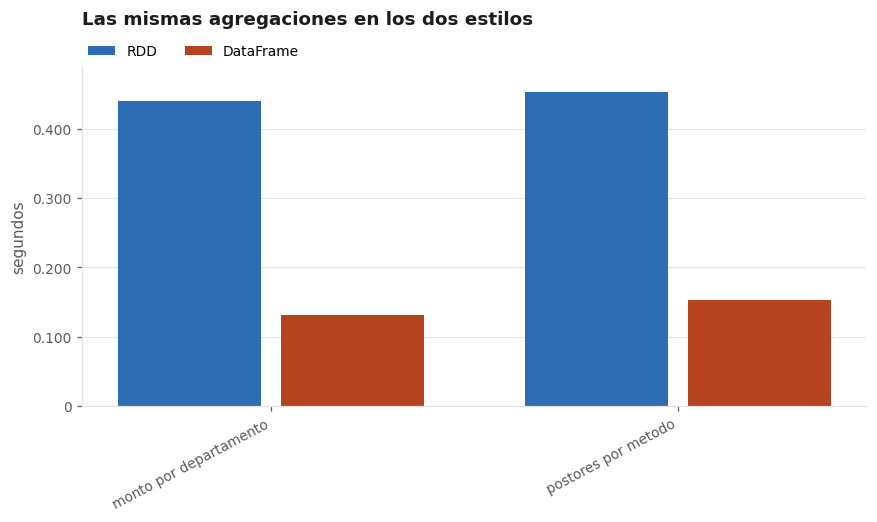

In [24]:
tt = pd.DataFrame(tiempos)
tt["factor"] = (tt.RDD / tt.DataFrame).round(1)
exportar(tt.round(4), "p1_tiempos", "Tiempo de las dos agregaciones en ambos estilos")

fig, _ = barras_agrupadas(tt, "agregacion", ["RDD", "DataFrame"],
                          "Las mismas agregaciones en los dos estilos", "segundos")
figura(fig, "f14_rdd_vs_dataframe", f"""
El camino RDD resulta entre {tt.factor.min()} y {tt.factor.max()} veces más lento, y no por
gusto: cada fila cruza la frontera entre la máquina virtual de Java y el intérprete de Python, y
el planificador no puede podar columnas ni reordenar filtros sobre tuplas opacas. Con 177 mil
filas ambos terminan en menos de un segundo, así que aquí la elección se decide por claridad;
la brecha crece con el volumen y es ahí donde empieza a costar dinero.""")
tt

| Aspecto | MapReduce sobre RDD | DataFrame y Spark SQL |
| --- | --- | --- |
| Qué se escribe | Cómo transformar cada fila y cómo combinar los parciales | Qué resultado se quiere; el planificador decide cómo |
| Esquema | Spark ve tuplas opacas, no valida nombres ni tipos hasta ejecutar | Un error de columna se detecta al planificar |
| Optimización | La que escriba a mano el programador | Catalyst poda columnas, reordena filtros y elige la unión |
| Serialización | Cada fila cruza a Python, y ese es el costo dominante | El cómputo se queda en la máquina virtual de Java |
| Cuándo conviene igual | Estado entre elementos, estructuras propias, algoritmos iterativos | Seleccionar, filtrar, agrupar, unir y agregar |

El EDA va en DataFrames sin discusión. Los RDD se reservan para lo que de verdad los necesita: las firmas MinHash y las bandas de LSH en la Parte II, y el recorrido con estado de la Parte IV.

## 7. Particionado y plan de ejecución

Una partición es la unidad de paralelismo: Spark lanza una tarea por partición. Dos decisiones se verifican aquí leyendo el plan, no suponiéndolo.

In [25]:
print("=== filtro sobre la columna de particion ===")
(spark.read.parquet(str(PARQUET)).filter("anio = 2024")
 .groupBy("categoria").count().explain(mode="formatted"))

=== filtro sobre la columna de particion ===
== Physical Plan ==
AdaptiveSparkPlan (6)
+- HashAggregate (5)
   +- Exchange (4)
      +- HashAggregate (3)
         +- Project (2)
            +- Scan parquet  (1)


(1) Scan parquet 
Output [2]: [categoria#783103, anio#783120]
Batched: true
Location: InMemoryFileIndex [file:/home/germain/Documentos/Python_Projects/DataMining/PROYECTO/data/processed/tabla_analitica.parquet]
PartitionFilters: [isnotnull(anio#783120), (anio#783120 = 2024)]
ReadSchema: struct<categoria:string>

(2) Project
Output [1]: [categoria#783103]
Input [2]: [categoria#783103, anio#783120]

(3) HashAggregate
Input [1]: [categoria#783103]
Keys [1]: [categoria#783103]
Functions [1]: [partial_count(1)]
Aggregate Attributes [1]: [count#783149L]
Results [2]: [categoria#783103, count#783150L]

(4) Exchange
Input [2]: [categoria#783103, count#783150L]
Arguments: hashpartitioning(categoria#783103, 16), ENSURE_REQUIREMENTS, [plan_id=9288]

(5) HashAggregate
Input [2]: [categoria

In [26]:
print("=== filtro sobre una columna NO particionada ===")
(spark.read.parquet(str(PARQUET)).filter("categoria = 'works'")
 .groupBy("anio").count().explain(mode="formatted"))

=== filtro sobre una columna NO particionada ===
== Physical Plan ==
AdaptiveSparkPlan (7)
+- HashAggregate (6)
   +- Exchange (5)
      +- HashAggregate (4)
         +- Project (3)
            +- Filter (2)
               +- Scan parquet  (1)


(1) Scan parquet 
Output [2]: [categoria#783158, anio#783175]
Batched: true
Location: InMemoryFileIndex [file:/home/germain/Documentos/Python_Projects/DataMining/PROYECTO/data/processed/tabla_analitica.parquet]
PushedFilters: [IsNotNull(categoria), EqualTo(categoria,works)]
ReadSchema: struct<categoria:string>

(2) Filter
Input [2]: [categoria#783158, anio#783175]
Condition : (isnotnull(categoria#783158) AND (categoria#783158 = works))

(3) Project
Output [1]: [anio#783175]
Input [2]: [categoria#783158, anio#783175]

(4) HashAggregate
Input [1]: [anio#783175]
Keys [1]: [anio#783175]
Functions [1]: [partial_count(1)]
Aggregate Attributes [1]: [count#783204L]
Results [2]: [anio#783175, count#783205L]

(5) Exchange
Input [2]: [anio#783175, count#7

En el primer plan la condición del año aparece en PartitionFilters: Spark la resuelve en el catálogo de archivos antes de leer un byte y abre un directorio de tres. En el segundo aparece en PushedFilters, así que abre los tres pero usa las estadísticas por grupo de filas de Parquet para saltar bloques sin descomprimirlos. Es una optimización real pero de segundo orden frente a no abrir el archivo.

La columna de partición se elige por cómo se consulta la tabla. El año es la correcta porque toda la Parte IV la recorre en orden temporal. Particionar por departamento habría dado veinticinco directorios muy desiguales, con Lima concentrando casi todo, y esa asimetría se paga en cada barajado.


Lectura de f15_shuffle
Con ejecución adaptativa el parámetro casi no cambia el tiempo: Spark conoce el tamaño real de la salida del barajado y fusiona las particiones pequeñas, así que doscientas declaradas terminan siendo unas pocas efectivas. Al desactivarla aparece el efecto que predice la teoría: 0.32 s con 200 particiones frente a 0.14 s con 16, porque planificar y recoger doscientas tareas de unos cientos de filas cuesta más que el cálculo. La regla de dos a cuatro veces el número de núcleos sigue siendo razonable, y la ejecución adaptativa es lo que evita pagar de inmediato una mala elección.



modo,particiones,adaptativo activo,adaptativo desactivado
0,4,0.152,0.125
1,16,0.125,0.144
2,64,0.164,0.192
3,200,0.176,0.316


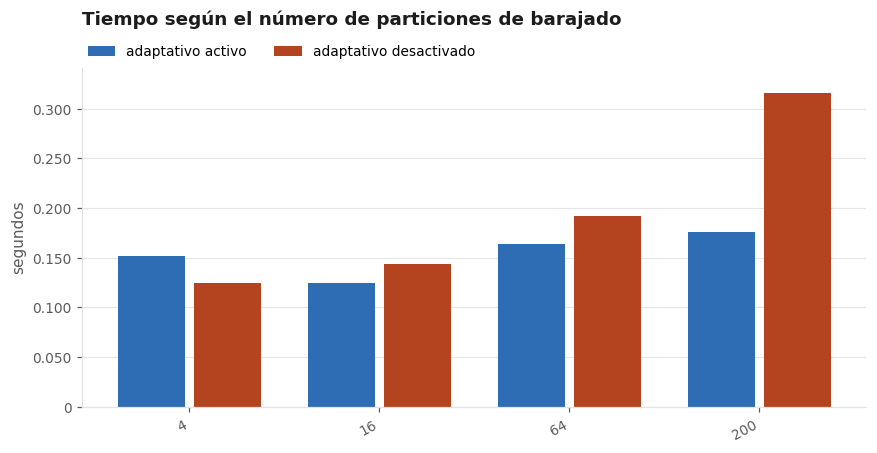

In [27]:
# Se mide dos veces: con ejecucion adaptativa, que es la configuracion real, y
# sin ella, que es lo que aisla el efecto del parametro.
prueba = []
for adaptativo in (True, False):
    for n_part in (4, 16, 64, 200):
        spark.conf.set("spark.sql.adaptive.enabled", str(adaptativo).lower())
        spark.conf.set("spark.sql.shuffle.partitions", str(n_part))
        spark.catalog.clearCache()
        seg = medir(lambda: (spark.read.parquet(str(PARQUET))
                                   .groupBy("departamento", "categoria", "metodo")
                                   .agg(F.sum("monto_pen"), F.count("*")).collect()), 3)
        prueba.append({"particiones": n_part, "segundos": round(seg, 3),
                       "modo": "adaptativo activo" if adaptativo else "adaptativo desactivado"})
spark.conf.set("spark.sql.adaptive.enabled", "true")
spark.conf.set("spark.sql.shuffle.partitions", "16")

pv = pd.DataFrame(prueba).pivot(index="particiones", columns="modo", values="segundos").reset_index()
exportar(pv, "p1_shuffle", "Tiempo de una agregacion segun particiones de barajado")

fig, _ = barras_agrupadas(pv.assign(particiones=pv.particiones.astype(str)), "particiones",
                          ["adaptativo activo", "adaptativo desactivado"],
                          "Tiempo según el número de particiones de barajado", "segundos")
sin = pv.set_index("particiones")["adaptativo desactivado"]
figura(fig, "f15_shuffle", f"""
Con ejecución adaptativa el parámetro casi no cambia el tiempo: Spark conoce el tamaño real de
la salida del barajado y fusiona las particiones pequeñas, así que doscientas declaradas
terminan siendo unas pocas efectivas. Al desactivarla aparece el efecto que predice la teoría:
{sin[200]:.2f} s con 200 particiones frente a {sin[16]:.2f} s con 16, porque planificar y
recoger doscientas tareas de unos cientos de filas cuesta más que el cálculo. La regla de dos a
cuatro veces el número de núcleos sigue siendo razonable, y la ejecución adaptativa es lo que
evita pagar de inmediato una mala elección.""")
pv

## 8. Qué hereda cada parte

La tabla persistida deja listas tres representaciones que no hay que volver a construir.

1. El objeto contractual normalizado y con la codificación reparada, del que salen los shingles de la Parte II y los vectores TF-IDF de la Parte III.
2. El conjunto de códigos CUBSO por proceso, entrada de Jaccard y MinHash en la Parte II y base de la canasta de la Parte V.
3. La fecha de convocatoria con resolución de minuto, que ordena el flujo simulado de la Parte IV.

Respuestas preliminares. La concentración es alta a nivel nacional pero está empujada por Lima, y falta saber si esos proveedores distintos son en realidad la misma empresa, que es lo que responde la Parte II. La competencia tiene un suelo de uno de cada diez procesos sin postores efectivos que atraviesa todos los tramos, y falta saber en qué combinaciones de entidad, rubro y método se concentra, que es lo que responde la Parte V.

In [28]:
exportar(pd.DataFrame(FIGURAS), "p1_figuras", "Figuras de la Parte I con su lectura")
print(pd.DataFrame(FIGURAS).to_string(index=False))
spark.stop()

                figura                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 lectura
   f01_paquete_vs_anio                                                                                                                                                                                                   Si cada paquete trajera solo sus propios procesos, toda la masa estaría en la diagonal. No es así: 82,946 filas corresponden a c